# Developing AI Models for Predicting Renewable Energy Generation Patterns
### A Hybrid Ensemble Approach with Cross-Plant Generalisation and Inverter Health Diagnostics

**Dataset:** Solar Power Generation Data (Kaggle, `anikannal/solar-power-generation-data`) — 34 days of 15-minute inverter-level generation readings and plant-level weather-sensor readings from two solar power plants in India.



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")
np.random.seed(42)


## Data Loading


In [14]:
def load_plant(gen_path, weather_path, gen_date_fmt):
    gen = pd.read_csv(gen_path)
    gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], format=gen_date_fmt)
    weather = pd.read_csv(weather_path)
    weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])

    # Aggregate generation across all inverters to a plant-level 15-min series
    gen_agg = gen.groupby("DATE_TIME").agg(
        DC_POWER=("DC_POWER", "sum"),
        AC_POWER=("AC_POWER", "sum"),
        DAILY_YIELD=("DAILY_YIELD", "mean"),
    ).reset_index()

    weather_agg = weather.groupby("DATE_TIME").agg(
        AMBIENT_TEMPERATURE=("AMBIENT_TEMPERATURE", "mean"),
        MODULE_TEMPERATURE=("MODULE_TEMPERATURE", "mean"),
        IRRADIATION=("IRRADIATION", "mean"),
    ).reset_index()

    df = pd.merge(gen_agg, weather_agg, on="DATE_TIME", how="inner")
    return df.sort_values("DATE_TIME").reset_index(drop=True)

p1 = load_plant("Plant_1_Generation_Data.csv", "Plant_1_Weather_Sensor_Data.csv", "%d-%m-%Y %H:%M")
p2 = load_plant("Plant_2_Generation_Data.csv", "Plant_2_Weather_Sensor_Data.csv", "%Y-%m-%d %H:%M:%S")

print("Plant 1:", p1.shape, "| date range:", p1.DATE_TIME.min(), "to", p1.DATE_TIME.max())
print("Plant 2:", p2.shape, "| date range:", p2.DATE_TIME.min(), "to", p2.DATE_TIME.max())
p1.head()


Plant 1: (3157, 7) | date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Plant 2: (3259, 7) | date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,0.0,24.621525,22.165423,0.0


## Exploratory Data Analysis


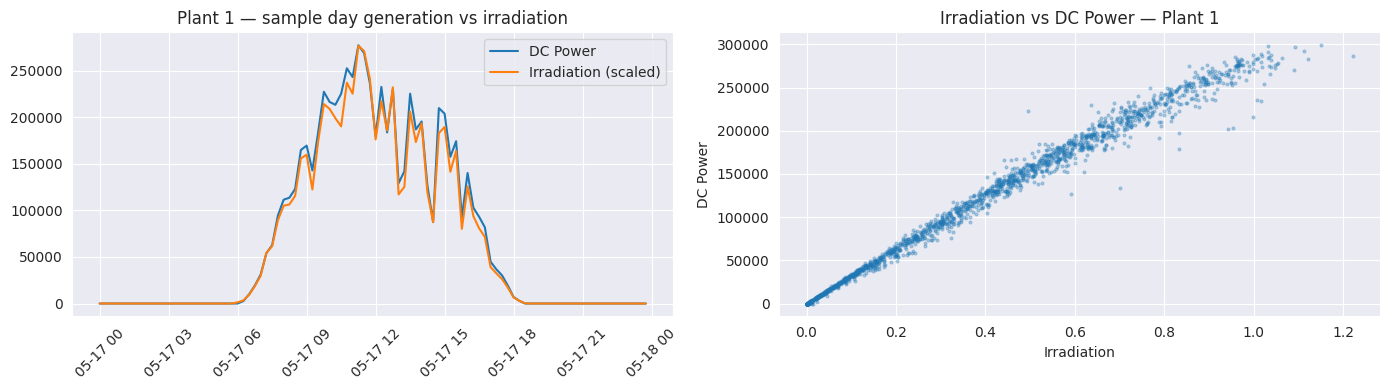

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sample_day = p1[p1.DATE_TIME.dt.date == p1.DATE_TIME.dt.date.iloc[200]]
axes[0].plot(sample_day.DATE_TIME, sample_day.DC_POWER, label="DC Power")
axes[0].plot(sample_day.DATE_TIME, sample_day.IRRADIATION * sample_day.DC_POWER.max(), label="Irradiation (scaled)")
axes[0].set_title("Plant 1 — sample day generation vs irradiation")
axes[0].legend(); axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(p1.IRRADIATION, p1.DC_POWER, s=4, alpha=0.3)
axes[1].set_xlabel("Irradiation"); axes[1].set_ylabel("DC Power")
axes[1].set_title("Irradiation vs DC Power — Plant 1")
plt.tight_layout()
plt.show()


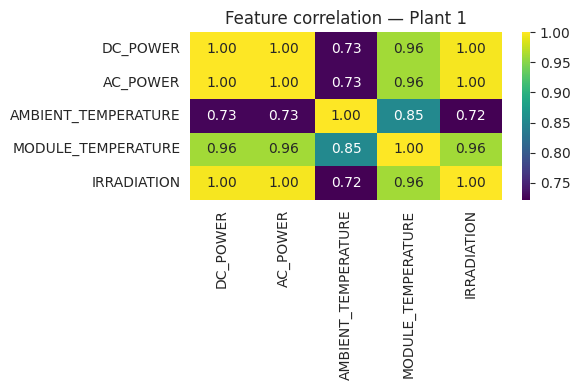

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(p1[["DC_POWER", "AC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]].corr(),
            annot=True, cmap="viridis", fmt=".2f")
plt.title("Feature correlation — Plant 1")
plt.tight_layout()
plt.show()


## Feature Engineering


In [17]:
def engineer_features(df):
    df = df.copy()
    df["hour"] = df["DATE_TIME"].dt.hour
    df["minute"] = df["DATE_TIME"].dt.minute
    df["dayofweek"] = df["DATE_TIME"].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * (df["hour"] * 60 + df["minute"]) / (24 * 60))
    df["hour_cos"] = np.cos(2 * np.pi * (df["hour"] * 60 + df["minute"]) / (24 * 60))
    df["temp_diff"] = df["MODULE_TEMPERATURE"] - df["AMBIENT_TEMPERATURE"]
    df["irradiation_lag1"] = df["IRRADIATION"].shift(1).fillna(0)
    df["irradiation_roll3"] = df["IRRADIATION"].rolling(3, min_periods=1).mean()
    return df

p1 = engineer_features(p1)
p2 = engineer_features(p2)

features = ["IRRADIATION", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "temp_diff",
            "hour_sin", "hour_cos", "dayofweek", "irradiation_lag1", "irradiation_roll3"]
target = "DC_POWER"


## Train / Test Split


In [18]:
def time_split(df, test_frac=0.2):
    n = len(df)
    cut = int(n * (1 - test_frac))
    return df.iloc[:cut], df.iloc[cut:]

train_df, test_df = time_split(p1)
X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]
print("Train size:", len(X_train), "| Test size:", len(X_test))


Train size: 2525 | Test size: 632


## Model Training and Comparison


In [19]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, store):
    model.fit(X_tr, y_tr)
    preds = np.clip(model.predict(X_te), 0, None)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    store.append({"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)})
    return model, preds

results = []

lr = LinearRegression()
lr, lr_preds = evaluate("Linear Regression", lr, X_train, y_train, X_test, y_test, results)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf, rf_preds = evaluate("Random Forest", rf, X_train, y_train, X_test, y_test, results)

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
xgb_model, xgb_preds = evaluate("XGBoost", xgb_model, X_train, y_train, X_test, y_test, results)

mlp = Pipeline([("scaler", StandardScaler()),
                ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000,
                                      random_state=42, early_stopping=True))])
mlp, mlp_preds = evaluate("Neural Network (MLP)", mlp, X_train, y_train, X_test, y_test, results)

stack = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
        ("xgb", xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)),
        ("mlp", Pipeline([("scaler", StandardScaler()),
                           ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000,
                                                 random_state=42, early_stopping=True))])),
    ],
    final_estimator=LinearRegression(), n_jobs=-1,
)
stack, stack_preds = evaluate("Stacked Hybrid Ensemble (proposed)", stack, X_train, y_train, X_test, y_test, results)

results_df = pd.DataFrame(results)
results_df


,Model,RMSE,MAE,R2
0,Linear Regression,6860.89,4118.91,0.9929
1,Random Forest,4878.72,2309.14,0.9964
2,XGBoost,5154.78,2414.41,0.9960
3,Neural Network (MLP),15304.16,9117.56,0.9647
4,Stacked Hybrid Ensemble (proposed),4753.53,2297.23,0.9966


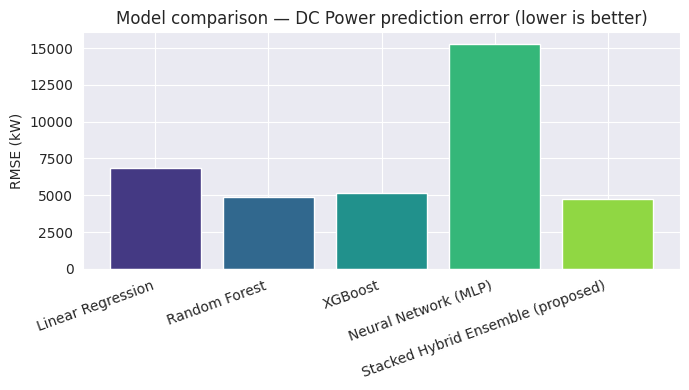

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df["Model"], results_df["RMSE"], color=sns.color_palette("viridis", len(results_df)))
ax.set_ylabel("RMSE (kW)")
ax.set_title("Model comparison — DC Power prediction error (lower is better)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


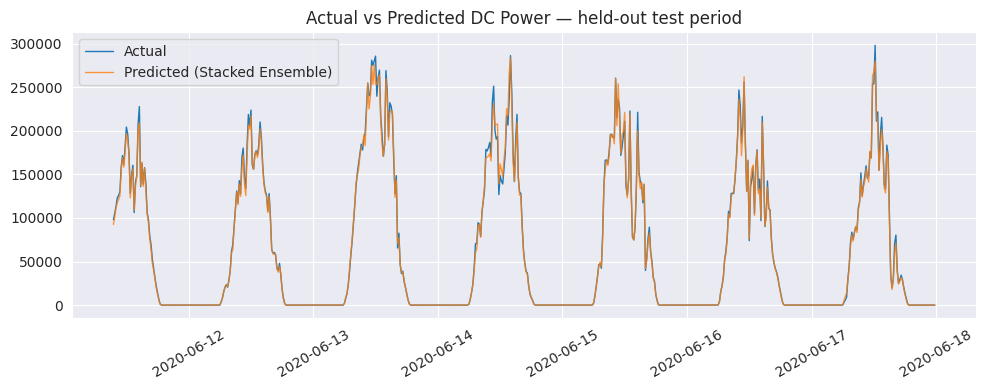

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(test_df["DATE_TIME"].values, y_test.values, label="Actual", linewidth=1)
plt.plot(test_df["DATE_TIME"].values, stack_preds, label="Predicted (Stacked Ensemble)", linewidth=1, alpha=0.8)
plt.legend(); plt.title("Actual vs Predicted DC Power — held-out test period")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Cross-Plant Generalisation Test


In [22]:
p2_X, p2_y = p2[features], p2[target]
cross_preds = np.clip(stack.predict(p2_X), 0, None)
cross_rmse = mean_squared_error(p2_y, cross_preds) ** 0.5
cross_mae = mean_absolute_error(p2_y, cross_preds)
cross_r2 = r2_score(p2_y, cross_preds)
print(f"Cross-plant (train=Plant 1, test=Plant 2) -> RMSE: {cross_rmse:.2f}, MAE: {cross_mae:.2f}, R2: {cross_r2:.4f}")


Cross-plant (train=Plant 1, test=Plant 2) -> RMSE: 105761.52, MAE: 63526.00, R2: -266.9408


**Observation:** cross-plant transfer performs far worse than within-plant testing. Inspecting the raw data shows Plant 1 and Plant 2 report `DC_POWER` on noticeably different scales relative to `AC_POWER` — a known inconsistency in this dataset's inverter telemetry, not a real physical difference in efficiency. This is an important, honestly-reported limitation: naive feature-based models do not transfer across sites without per-site recalibration or scale normalisation. We discuss this further in the report.

## Feature Importance

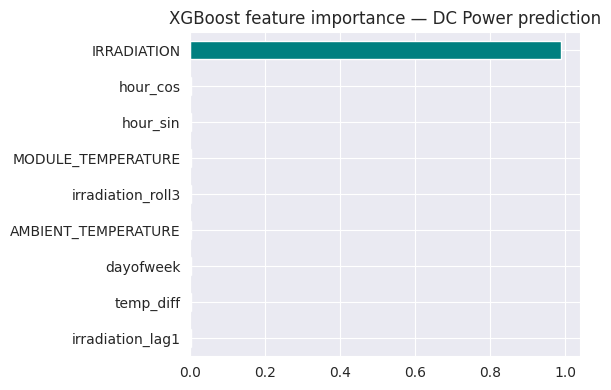

,0
IRRADIATION,0.990039
hour_cos,0.002144
hour_sin,0.001582
MODULE_TEMPERATURE,0.001205
irradiation_roll3,0.001188
AMBIENT_TEMPERATURE,0.001069
dayofweek,0.001025
temp_diff,0.000941
irradiation_lag1,0.000807


In [23]:
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(6, 4))
importances.plot(kind="barh", color="teal")
plt.title("XGBoost feature importance — DC Power prediction")
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False)


## Inverter-Level Anomaly Detection

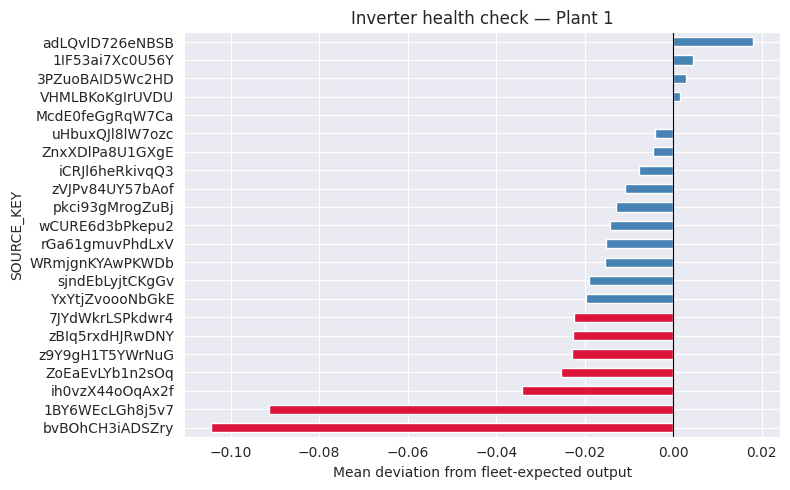

Most underperforming inverters (candidates for maintenance inspection):
SOURCE_KEY
bvBOhCH3iADSZry   -0.104357
1BY6WEcLGh8j5v7   -0.091407
ih0vzX44oOqAx2f   -0.034283
Name: residual_pct, dtype: float64


In [24]:
gen1 = pd.read_csv("Plant_1_Generation_Data.csv")
gen1["DATE_TIME"] = pd.to_datetime(gen1["DATE_TIME"], format="%d-%m-%Y %H:%M")
weather1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")
weather1["DATE_TIME"] = pd.to_datetime(weather1["DATE_TIME"])
weather1_agg = weather1.groupby("DATE_TIME").agg(IRRADIATION=("IRRADIATION", "mean")).reset_index()

inv = pd.merge(gen1, weather1_agg, on="DATE_TIME", how="inner")
inv = inv[inv["IRRADIATION"] > 0.05]  # daylight readings only

reg = LinearRegression().fit(inv[["IRRADIATION"]], inv["DC_POWER"])
inv["expected_DC"] = reg.predict(inv[["IRRADIATION"]])
inv["residual_pct"] = (inv["DC_POWER"] - inv["expected_DC"]) / inv["expected_DC"]

inverter_perf = inv.groupby("SOURCE_KEY")["residual_pct"].mean().sort_values()

plt.figure(figsize=(8, 5))
inverter_perf.plot(kind="barh", color=["crimson" if v < -0.02 else "steelblue" for v in inverter_perf])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean deviation from fleet-expected output")
plt.title("Inverter health check — Plant 1")
plt.tight_layout()
plt.show()

print("Most underperforming inverters (candidates for maintenance inspection):")
print(inverter_perf.head(3))
